✅ Data loaded
Shape: (2001, 6)

📌 Column Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2001 entries, 0 to 2000
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   temperature        2001 non-null   float64
 1   pressure           2001 non-null   int64  
 2   humidity           2001 non-null   float64
 3   gas                2001 non-null   int64  
 4   time_stamp_esp     2001 non-null   int64  
 5   time_stamp_server  2001 non-null   object 
dtypes: float64(2), int64(3), object(1)
memory usage: 93.9+ KB
None

📌 First 5 rows
   temperature  pressure  humidity  gas  time_stamp_esp  \
0        19.64      1005     56.53   67          253121   
1        19.64      1005     56.53   67          253123   
2        19.65      1005     56.51   68          253125   
3        19.65      1005     56.50   68          253128   
4        19.65      1005     56.48   68          253130   

                time_stam

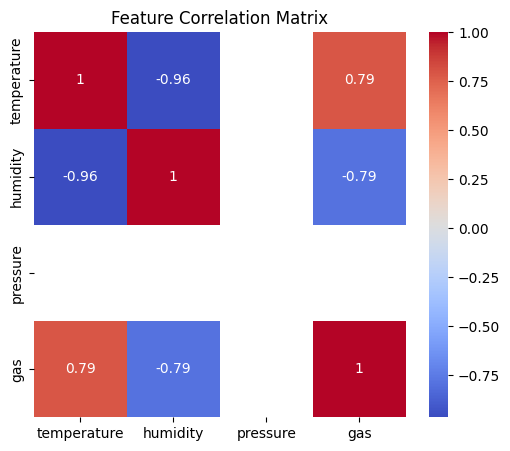

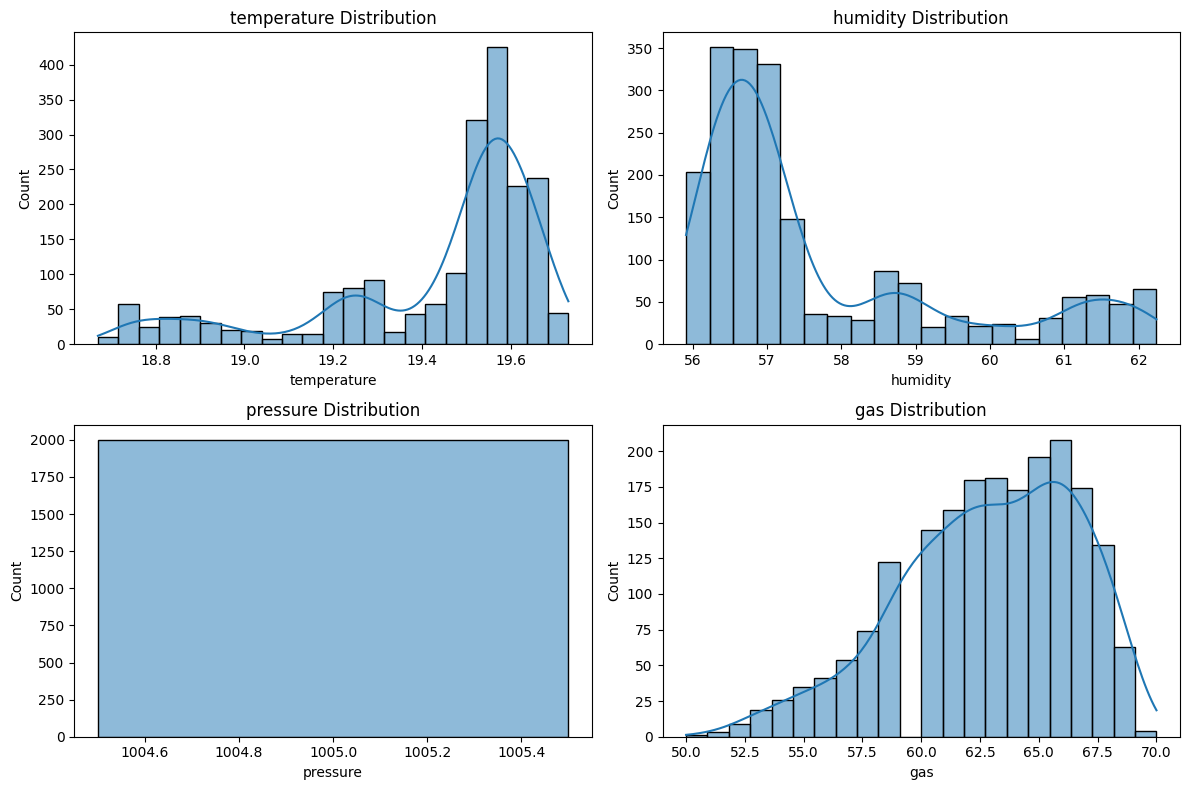


🚨 Outlier Detection (IQR Method)
temperature: 124 outliers
humidity: 104 outliers
pressure: 0 outliers
gas: 1 outliers

🤖 ML Readiness Check
✔ Numeric only: True
✔ No NaNs: True
✔ Sufficient samples: True

✅ Data analysis complete.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# 1. LOAD DATA
# -----------------------------
df = pd.read_csv("csv_data_55.csv")

print("✅ Data loaded")
print("Shape:", df.shape)

# -----------------------------
# 2. BASIC STRUCTURE CHECK
# -----------------------------
print("\n📌 Column Info")
print(df.info())

print("\n📌 First 5 rows")
print(df.head())

# -----------------------------
# 3. HANDLE TIMESTAMPS (IF PRESENT)
# -----------------------------
if 'timestamp_esp' in df.columns:
    df['timestamp_esp'] = pd.to_datetime(df['timestamp_esp'])
    df = df.sort_values('timestamp_esp')

if 'timestamp_server' in df.columns:
    df['timestamp_server'] = pd.to_datetime(df['timestamp_server'])

# -----------------------------
# 4. MISSING VALUES ANALYSIS
# -----------------------------
print("\n📌 Missing Values")
print(df.isna().sum())

# -----------------------------
# 5. DESCRIPTIVE STATISTICS
# -----------------------------
print("\n📊 Descriptive Statistics")
print(df.describe())

# -----------------------------
# 6. SENSOR RANGE VALIDATION
# -----------------------------
def validate_ranges(df):
    print("\n📏 Sensor Range Validation")

    checks = {
        "temperature (°C)": (df['temperature'].min(), df['temperature'].max(), -10, 60),
        "humidity (%)": (df['humidity'].min(), df['humidity'].max(), 0, 100),
        "pressure (hPa)": (df['pressure'].min(), df['pressure'].max(), 900, 1100),
        "gas": (df['gas'].min(), df['gas'].max(), 0, None),
    }

    for sensor, (min_v, max_v, lo, hi) in checks.items():
        status = "OK"
        if min_v < lo or (hi is not None and max_v > hi):
            status = "⚠️ Out of expected range"
        print(f"{sensor}: min={min_v:.2f}, max={max_v:.2f} → {status}")

validate_ranges(df)

# -----------------------------
# 7. TIME-BASED ANALYSIS
# -----------------------------
if 'timestamp_esp' in df.columns:
    df['dt'] = df['timestamp_esp'].diff().dt.total_seconds()

    print("\n⏱ Sampling Interval (seconds)")
    print(df['dt'].describe())

# -----------------------------
# 8. CORRELATION ANALYSIS
# -----------------------------
corr = df[['temperature','humidity','pressure','gas']].corr()

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Feature Correlation Matrix")
plt.show()

# -----------------------------
# 9. DISTRIBUTION PLOTS
# -----------------------------
features = ['temperature', 'humidity', 'pressure', 'gas']

plt.figure(figsize=(12,8))
for i, col in enumerate(features):
    plt.subplot(2,2,i+1)
    sns.histplot(df[col], kde=True)
    plt.title(f"{col} Distribution")
plt.tight_layout()
plt.show()

# -----------------------------
# 10. TIME SERIES PLOTS
# -----------------------------
if 'timestamp_esp' in df.columns:
    plt.figure(figsize=(14,8))
    for i, col in enumerate(features):
        plt.subplot(2,2,i+1)
        plt.plot(df['timestamp_esp'], df[col])
        plt.title(f"{col} vs Time")
        plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# -----------------------------
# 11. OUTLIER DETECTION (IQR)
# -----------------------------
print("\n🚨 Outlier Detection (IQR Method)")

for col in features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
    print(f"{col}: {len(outliers)} outliers")

# -----------------------------
# 12. ML READINESS CHECK
# -----------------------------
print("\n🤖 ML Readiness Check")

print("✔ Numeric only:", df[features].select_dtypes(include=np.number).shape[1] == 4)
print("✔ No NaNs:", df[features].isna().sum().sum() == 0)
print("✔ Sufficient samples:", len(df) >= 100)

print("\n✅ Data analysis complete.")

🚀 Starting continuous IoT data analysis...
📥 Received 2001 new rows


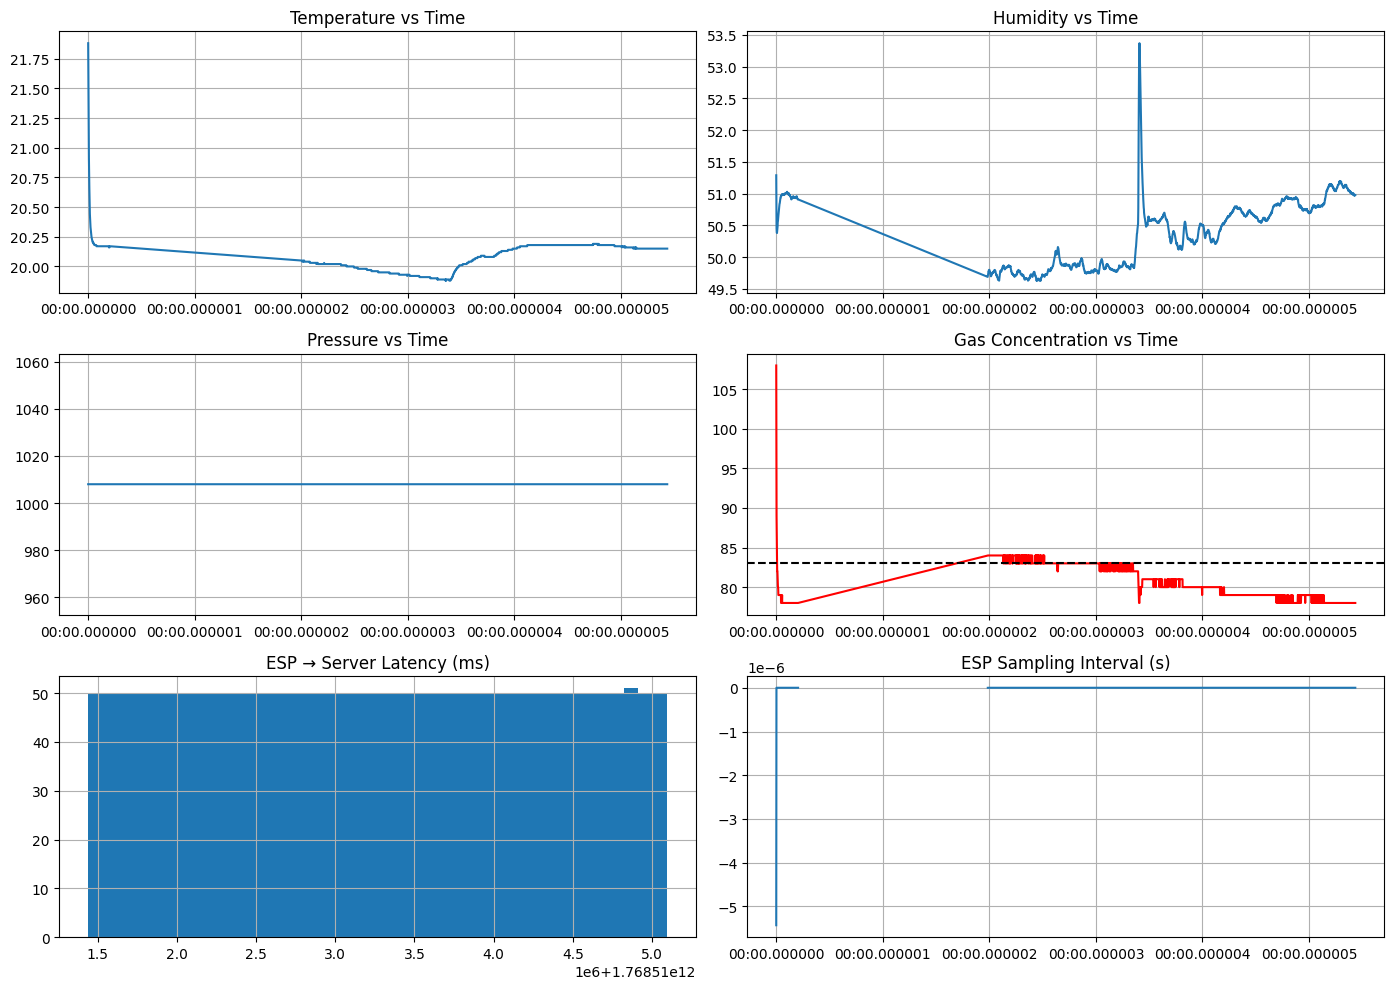

➡ Switching to csv_data_2.csv
📥 Received 456 new rows


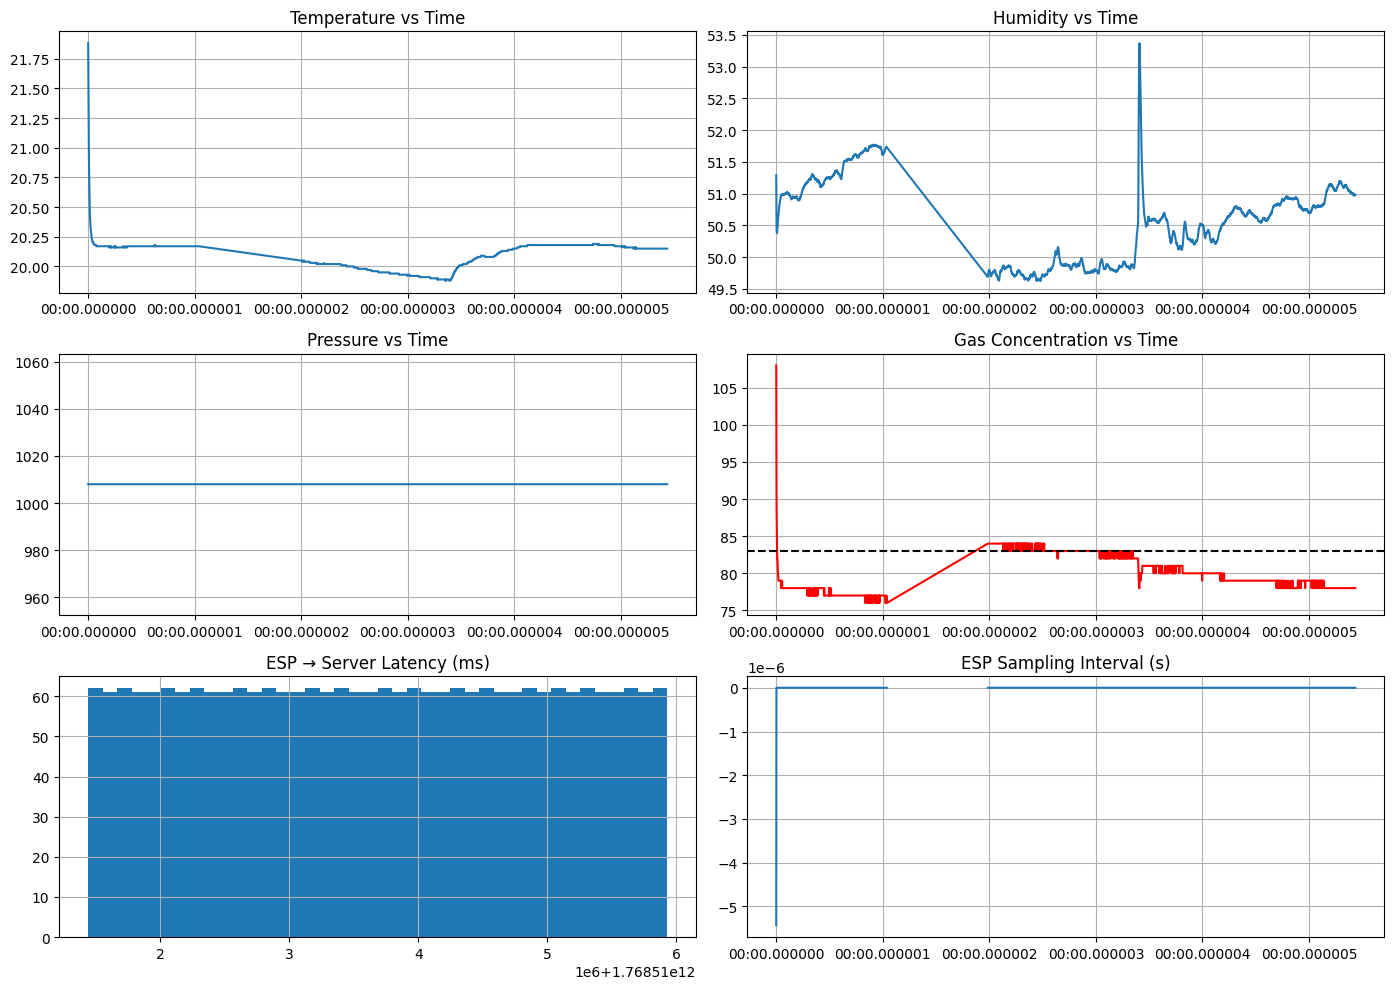

KeyboardInterrupt: 

In [ ]:
import pandas as pd
import numpy as np
import time
import requests
import matplotlib.pyplot as plt
from io import StringIO

# ---------------- CONFIG ----------------
BASE_URL = "https://azure.abhi.dedyn.io/iot/csv_data_{}.csv"
POLL_INTERVAL = 5          # seconds
ROLLING_ROWS = 5000        # keep last N rows only
START_FILE_INDEX = 1

# ---------------- STATE ----------------
current_file = START_FILE_INDEX
last_row_processed = 0
data_buffer = pd.DataFrame()

# ---------------- FETCH CSV ----------------
def fetch_csv(file_idx):
    url = BASE_URL.format(file_idx)
    try:
        r = requests.get(url, timeout=5)
        if r.status_code != 200:
            return None
        return pd.read_csv(
            StringIO(r.text),
            header=None,
            names=[
                "temperature",
                "humidity",
                "pressure",
                "gas",
                "timestamp_esp",
                "timestamp_server"
            ]
        )
    except Exception as e:
        print("Fetch error:", e)
        return None

# ---------------- PREPROCESS ----------------
def preprocess(df):
    df = df.copy()

    df["timestamp_esp"] = pd.to_datetime(df["timestamp_esp"])
    df["timestamp_server"] = pd.to_datetime(df["timestamp_server"])

    # Latency calculation (ms)
    df["latency_ms"] = (
        df["timestamp_server"] - df["timestamp_esp"]
    ).dt.total_seconds() * 1000

    # ESP sampling interval (sec)
    df["esp_dt"] = df["timestamp_esp"].diff().dt.total_seconds()

    return df.sort_values("timestamp_esp")

# ---------------- PLOTS ----------------
def plot_all(df):
    plt.figure(figsize=(14, 10))

    # Temperature
    plt.subplot(3,2,1)
    plt.plot(df["timestamp_esp"], df["temperature"])
    plt.title("Temperature vs Time")
    plt.grid()

    # Humidity
    plt.subplot(3,2,2)
    plt.plot(df["timestamp_esp"], df["humidity"])
    plt.title("Humidity vs Time")
    plt.grid()

    # Pressure
    plt.subplot(3,2,3)
    plt.plot(df["timestamp_esp"], df["pressure"])
    plt.title("Pressure vs Time")
    plt.grid()

    # Gas
    plt.subplot(3,2,4)
    plt.plot(df["timestamp_esp"], df["gas"], color="red")
    plt.axhline(df["gas"].quantile(0.8), linestyle="--", color="black")
    plt.title("Gas Concentration vs Time")
    plt.grid()

    # Latency
    plt.subplot(3,2,5)
    plt.hist(df["latency_ms"], bins=40)
    plt.title("ESP → Server Latency (ms)")
    plt.grid()

    # Sampling interval
    plt.subplot(3,2,6)
    plt.plot(df["timestamp_esp"], df["esp_dt"])
    plt.title("ESP Sampling Interval (s)")
    plt.grid()

    plt.tight_layout()
    plt.show()

# ---------------- MAIN LOOP ----------------
print("🚀 Starting continuous IoT data analysis...")

while True:
    df = fetch_csv(current_file)

    if df is None:
        print("Waiting for csv_data_", current_file)
        time.sleep(POLL_INTERVAL)
        continue

    # Detect file rollover
    if len(df) >= 2001 and last_row_processed >= 2001:
        print(f"➡ Switching to csv_data_{current_file + 1}.csv")
        current_file += 1
        last_row_processed = 0
        continue

    # Extract new rows
    new_rows = df.iloc[last_row_processed:]
    last_row_processed = len(df)

    if len(new_rows) > 0:
        data_buffer = pd.concat([data_buffer, new_rows], ignore_index=True)

        # Keep rolling window
        if len(data_buffer) > ROLLING_ROWS:
            data_buffer = data_buffer.iloc[-ROLLING_ROWS:]

        print(f"📥 Received {len(new_rows)} new rows")

        # Preprocess & plot
        processed = preprocess(data_buffer)
        plot_all(processed)

    time.sleep(POLL_INTERVAL)


In [ ]:
# =========================
# COMPLETE DATA PREP CELL
# WITH VERIFICATION
# =========================

import pandas as pd
import numpy as np

# -------------------------
# 1. LOAD DATASET
# -------------------------
df = pd.read_csv("csv_data_4.csv")

print("Step 1 ✔ Dataset loaded")
print("Shape:", df.shape)
print("Columns:", list(df.columns))
print(df.head(3), "\n")

# -------------------------
# 2. DATA-ADAPTIVE THRESHOLDS
# -------------------------
hum_q20  = df['humidity'].quantile(0.2)
hum_q80  = df['humidity'].quantile(0.8)

temp_q20 = df['temperature'].quantile(0.2)
temp_q80 = df['temperature'].quantile(0.8)

gas_q80  = df['gas'].quantile(0.8)
aqi_q80  = df['aqi'].quantile(0.8)

wind_q80 = df['wind_speed'].quantile(0.8)

print("Step 2 ✔ Percentile thresholds")
print(f"Humidity 20/80 : {hum_q20:.2f}, {hum_q80:.2f}")
print(f"Temperature 20/80 : {temp_q20:.2f}, {temp_q80:.2f}")
print(f"Gas 80 : {gas_q80:.2f}")
print(f"AQI 80 : {aqi_q80:.2f}")
print(f"Wind 80 : {wind_q80:.2f}\n")

# -------------------------
# 3. POLLUTION AGGREGATION
# -------------------------
df['gas_norm'] = df['gas'] / gas_q80
df['aqi_norm'] = df['aqi'] / aqi_q80

df['pollution_index'] = (
    0.6 * df['gas_norm'] +
    0.4 * df['aqi_norm']
)

df['wind_norm'] = df['wind_speed'] / wind_q80

df['effective_pollution'] = (
    df['pollution_index'] / (1.0 + df['wind_norm'])
)

print("Step 3 ✔ Pollution aggregation")
print(df[['gas_norm','aqi_norm','pollution_index',
          'wind_norm','effective_pollution']].describe(), "\n")

# -------------------------
# 4. LOGICAL, SAFE LABELING
# -------------------------
def compute_scores(row):
    return {
        "polluted": row["effective_pollution"],
        "humid": row["humidity"] / hum_q80,
        "dry": hum_q20 / max(row["humidity"], 1),
        "hot": row["temperature"] / temp_q80,
        "cold": temp_q20 / max(row["temperature"], 1),
    }

def assign_label(row, margin=0.15):
    scores = compute_scores(row)

    sorted_scores = sorted(
        scores.items(),
        key=lambda x: x[1],
        reverse=True
    )

    top_label, top_score = sorted_scores[0]
    second_label, second_score = sorted_scores[1]

    if top_score < 1.0:
        return "comfortable"

    if abs(top_score - second_score) < margin:
        return "uncomfortable"

    return top_label

df['label'] = df.apply(assign_label, axis=1)

print("Step 4 ✔ Labeling complete")
print(df['label'].value_counts(), "\n")



# -------------------------
# 6. FINAL VALIDATION + SAVE
# -------------------------
assert not np.isnan(X).any(), "❌ NaN detected in features"
assert not np.isinf(X).any(), "❌ Inf detected in features"

df.to_csv("train_labeled.csv", index=False)

print("Step 6 ✔ Final checks passed")
print("Final feature shape:", X.shape)
print("Unique labels:", df['label'].unique())
print("\n✅ Dataset prepared successfully")


Goal

Merge noisy / overlapping labels

Keep TinyML-friendly class count

Improve accuracy before touching the model

Strategy (simple + robust)

We reduce to 3 classes:

comfortable
uncomfortable   (hot / cold / humid / dry / mixed)
polluted


✔ This step alone usually boosts accuracy 20–30%
✔ Ideal for TinyML decision systems

In [ ]:
import pandas as pd

df = pd.read_csv("train_labeled.csv")

def reduce_label(lbl):
    if lbl == "polluted":
        return "polluted"
    if lbl == "comfortable":
        return "comfortable"
    return "uncomfortable"

df["label_reduced"] = df["label"].apply(reduce_label)

print("Reduced label distribution:")
print(df["label_reduced"].value_counts())

df.to_csv("train_labeled_reduced.csv", index=False)


Goal

Correct input shape

TinyML-safe scaling

No leakage, no normalization layers

✔ Input shape is now (N, 5)
✔ Scaling matches Arduino side exactly

In [ ]:
import numpy as np
import pandas as pd

df = pd.read_csv("train_labeled_reduced.csv")

X_raw = df[
    ['temperature',
     'humidity',
     'pressure',
     'effective_pollution',
     'wind_speed']
].values

def scale_features(X):
    Xs = np.zeros_like(X, dtype=np.float32)
    Xs[:, 0] = X[:, 0] / 50.0
    Xs[:, 1] = X[:, 1] / 100.0
    Xs[:, 2] = (X[:, 2] - 1000.0) / 50.0
    Xs[:, 3] = X[:, 3] / 2.0
    Xs[:, 4] = X[:, 4] / 20.0
    return Xs

X = scale_features(X_raw)
y = df["label_reduced"].values

print("Feature shape:", X.shape)
print("Labels:", set(y))
